In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV-Datei einlesen
df = pd.read_csv('verteilung_segmente_pro_partei_zeitraum_topic.csv', sep=';')

df

,partei,zeitraum,Anzahl Segmente_Schulden,Anzahl Segmente_Migration,Anzahl Segmente_Ukraine,Anzahl Segmente_Bürgergeld
0,AfD,Wahlprogramm,84,104,29,70
1,AfD,01.01.-31.03.2022,56,9,31,12
2,AfD,01.10.-31.12.2023,70,29,16,31
3,AfD,01.10.-15.12.2024,64,26,16,21
4,AfD,01.01.-23.02.2025,7,11,3,2
5,AfD,01.05.-31.07.2025,109,46,40,29
6,CDU/CSU,Wahlprogramm,90,17,44,44
7,CDU/CSU,01.01.-31.03.2022,136,10,73,39
8,CDU/CSU,01.10.-31.12.2023,134,44,39,51
9,CDU/CSU,01.10.-15.12.2024,123,28,39,43


In [20]:
# Nur die Zeilen filtern, bei denen die Spalte 'zeitraum' exakt dem gesuchten Datum entspricht
df_vierte_periode = df[df['zeitraum'] == '01.01.-23.02.2025'].copy().style.hide(axis='index')

latex_code = df_vierte_periode.to_latex(caption='Vierte Periode', label='tab:meine_tabelle')
with open('tabelle_verteilung_vierter_zeitraum.tex', 'w') as f:
    f.write(latex_code)

# Das gefilterte Ergebnis anzeigen
df_vierte_periode

partei,zeitraum,Anzahl Segmente_Schulden,Anzahl Segmente_Migration,Anzahl Segmente_Ukraine,Anzahl Segmente_Bürgergeld,Summe_Segmente
AfD,01.01.-23.02.2025,7,11,3,2,23
CDU/CSU,01.01.-23.02.2025,17,11,5,11,44
FDP,01.01.-23.02.2025,12,20,4,4,40
Grüne,01.01.-23.02.2025,25,5,6,5,41
Linke,01.01.-23.02.2025,1,2,1,4,8
SPD,01.01.-23.02.2025,23,9,9,7,48


In [8]:
# 1. Definieren Sie die Spalten, die addiert werden sollen
themen_spalten = [
    'Anzahl Segmente_Schulden', 
    'Anzahl Segmente_Migration', 
    'Anzahl Segmente_Ukraine', 
    'Anzahl Segmente_Bürgergeld'
]

# 2. Berechnen Sie die zeilenweise Summe (axis=1 steht für Spaltenaddition)
df['Summe_Segmente'] = df[themen_spalten].sum(axis=1)

# Ergebnisse anzeigen lassen
print(df[['partei', 'zeitraum', 'Summe_Segmente']])


     partei           zeitraum  Summe_Segmente
0       AfD       Wahlprogramm             287
1       AfD  01.01.-31.03.2022             108
2       AfD  01.10.-31.12.2023             146
3       AfD  01.10.-15.12.2024             127
4       AfD  01.01.-23.02.2025              23
5       AfD  01.05.-31.07.2025             224
6   CDU/CSU       Wahlprogramm             195
7   CDU/CSU  01.01.-31.03.2022             258
8   CDU/CSU  01.10.-31.12.2023             268
9   CDU/CSU  01.10.-15.12.2024             233
10  CDU/CSU  01.01.-23.02.2025              44
11  CDU/CSU  01.05.-31.07.2025             388
12      FDP       Wahlprogramm              68
13      FDP  01.01.-31.03.2022             160
14      FDP  01.10.-31.12.2023             145
15      FDP  01.10.-15.12.2024             145
16      FDP  01.01.-23.02.2025              40
17    Grüne       Wahlprogramm             162
18    Grüne  01.01.-31.03.2022             170
19    Grüne  01.10.-31.12.2023             202
20    Grüne  

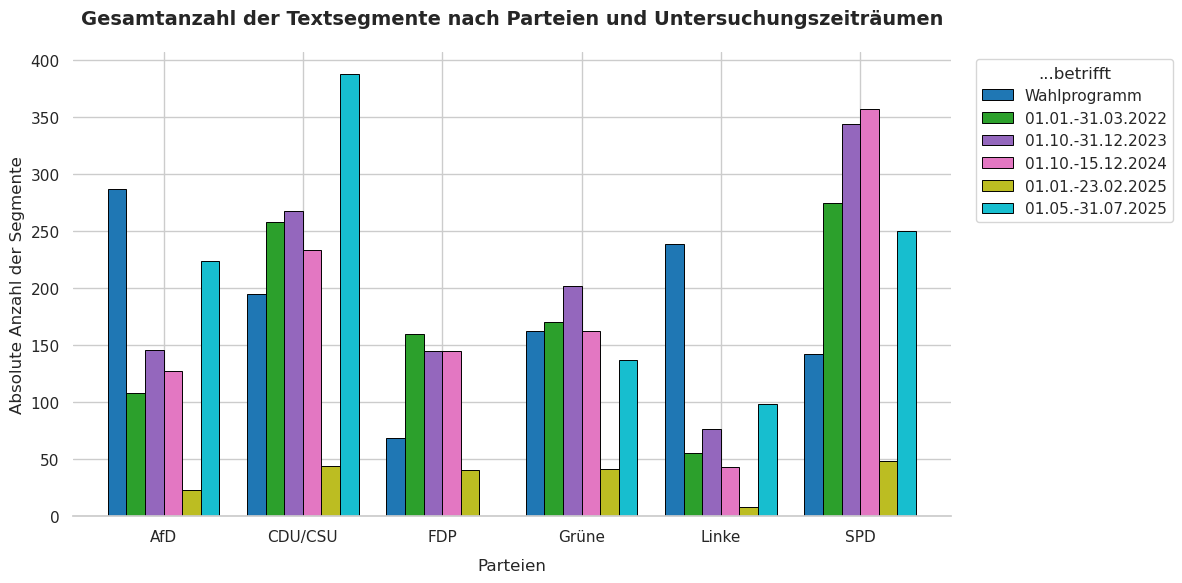

In [21]:
# 1. Akademischen Stil setzen
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Definieren Sie die exakte chronologische Reihenfolge
reihenfolge_zeitraeume = [
    'Wahlprogramm',
    '01.01.-31.03.2022',
    '01.10.-31.12.2023',
    '01.10.-15.12.2024',
    '01.01.-23.02.2025',
    '01.05.-31.07.2025'
]

# 2. Die Spalte in eine sortierbare Kategorie umwandeln
df['zeitraum'] = pd.Categorical(df['zeitraum'], categories=reihenfolge_zeitraeume, ordered=True)

# 3. Daten wie gewohnt umstellen (Pandas sortiert nun automatisch nach der neuen Reihenfolge)
df_plot = df.set_index(['partei', 'zeitraum'])['Summe_Segmente'].unstack(level=1)

# 4. Diagramm erstellen
fig, ax = plt.subplots(figsize=(12, 6))

# Dezente, wissenschaftliche Farbpalette für die Zeiträume wählen
# 'viridis', 'muted' oder eine eigene Farbpalette eignen sich hier hervorragend
df_plot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.7, cmap='tab10')

# 5. Achsenbeschriftungen und Titel optimieren
ax.set_title('Gesamtanzahl der Textsegmente nach Parteien und Untersuchungszeiträumen', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Parteien', fontsize=12, labelpad=10)
ax.set_ylabel('Absolute Anzahl der Segmente', fontsize=12)

# X-Achsen-Labels (Parteien) gerade ausrichten statt schräg
plt.xticks(rotation=0, fontsize=11)

# 6. Legende außerhalb oder elegant platzieren
ax.legend(title='...betrifft', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# 7. Wissenschaftliches Layout aufräumen (Spines reduzieren)
sns.despine(left=True, bottom=False)
plt.tight_layout()

# 8. Für die Masterarbeit als hochauflösende Vektorgrafik speichern
plt.savefig('segmente_pro_partei_zeitraum.pdf', dpi=300, bbox_inches='tight')
plt.show()


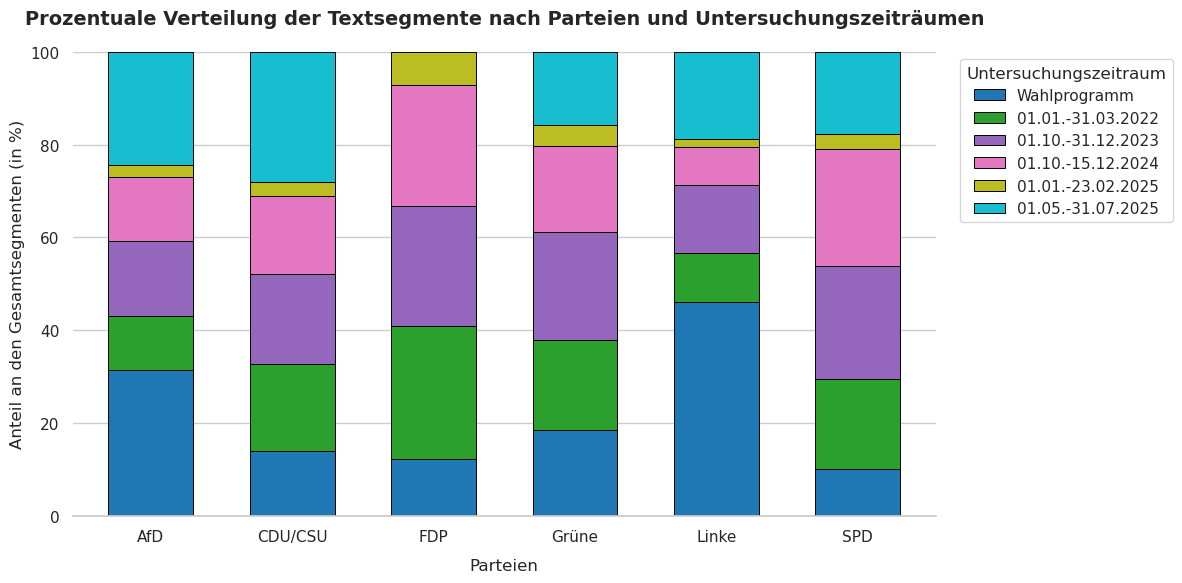

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Akademischen Stil setzen
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 2. Definieren Sie die exakte chronologische Reihenfolge
reihenfolge_zeitraeume = [
    'Wahlprogramm',
    '01.01.-31.03.2022',
    '01.10.-31.12.2023',
    '01.10.-15.12.2024',
    '01.01.-23.02.2025',
    '01.05.-31.07.2025'
]

# 3. Die Spalte in eine sortierbare Kategorie umwandeln
df['zeitraum'] = pd.Categorical(df['zeitraum'], categories=reihenfolge_zeitraeume, ordered=True)

# 4. Daten umstellen (sortiert automatisch chronologisch)
df_plot = df.set_index(['partei', 'zeitraum'])['Summe_Segmente'].unstack(level=1)

# --- NEU: ABSOLUTE WERTE IN PROZENT JWEILS PRO PARTEI UMRECHNEN (100% STACKED) ---
# Zeilensumme pro Partei bilden und jeden Wert durch diese teilen
df_prozent = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

# 5. Diagramm erstellen (stacked=True für gestapelte Balken)
fig, ax = plt.subplots(figsize=(12, 6))

# Gestapeltes Balkendiagramm plotten
df_prozent.plot(kind='bar', stacked=True, ax=ax, width=0.6, edgecolor='black', linewidth=0.7, cmap='tab10')

# 6. Achsenbeschriftungen und Titel für Prozentwerte anpassen
ax.set_title('Prozentuale Verteilung der Textsegmente nach Parteien und Untersuchungszeiträumen', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Parteien', fontsize=12, labelpad=10)
ax.set_ylabel('Anteil an den Gesamtsegmenten (in %)', fontsize=12)

# Y-Achse hart auf maximal 100 Prozent begrenzen
ax.set_ylim(0, 100)

# X-Achsen-Labels (Parteien) gerade ausrichten statt schräg
plt.xticks(rotation=0, fontsize=11)

# 7. Legende außerhalb oder elegant platzieren
ax.legend(title='Untersuchungszeitraum', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# 8. Wissenschaftliches Layout aufräumen (Spines reduzieren)
sns.despine(left=True, bottom=False)
plt.tight_layout()

# 9. Für die Masterarbeit als hochauflösende Vektorgrafik speichern
plt.savefig('prozent_segmente_pro_partei_zeitraum.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
# ENDE